# Event Studies

**Chapter 8: Feature Engineering**
**Section Reference**: 8.6 - Combining Features and Controlling Search
**Docker image**: `ml4t`

## Purpose

Event studies measure abnormal returns around specific events (signal triggers,
macro announcements, earnings) to assess their predictive power. This is a key
validation technique for trading signals.

## Learning Objectives

1. Understand event study methodology (MacKinlay 1997)
2. Implement correct abnormal return computation
3. Calculate CAAR with proper confidence bands
4. Use event studies for signal validation
5. Recognize common pitfalls (clustering, overlapping windows)

## Key Concepts

**Event Study Workflow**:
1. Define events (signal triggers, announcements)
2. Estimate "normal" returns in estimation window
3. Calculate abnormal returns in event window
4. Aggregate across events (CAAR)
5. Test statistical significance

## References

- MacKinlay, A.C. (1997). "Event Studies in Economics and Finance"
- Boehmer et al. (1991). Event-induced variance adjustments

## Data Policy

All examples use **real ETF data**.

In [1]:
"""Event Studies — measure abnormal returns around signal triggers and macro announcements."""

from __future__ import annotations

import warnings
from datetime import datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
from scipy import stats

from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
START_DATE = "2018-01-01"
END_DATE = "2024-01-01"
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Data Loading

We use ETF data to demonstrate event studies. Events will be generated from
momentum breakouts (trading signal) as a validation example.

In [4]:
from data import load_etfs

etfs = load_etfs()


# Select liquid ETFs for event study
SYMBOLS = ["SPY", "QQQ", "IWM", "TLT", "GLD"]

# Filter
etf_filtered = (
    etfs.filter(pl.col("symbol").is_in(SYMBOLS))
    .filter(
        (pl.col("timestamp") >= datetime.strptime(START_DATE, "%Y-%m-%d"))
        & (pl.col("timestamp") < datetime.strptime(END_DATE, "%Y-%m-%d"))
    )
    .sort(["symbol", "timestamp"])
)

print(f"ETF data: {len(etf_filtered):,} rows")
print(f"Symbols: {etf_filtered['symbol'].n_unique()}")
print(f"Date range: {etf_filtered['timestamp'].min()} to {etf_filtered['timestamp'].max()}")

ETF data: 7,545 rows
Symbols: 5
Date range: 2018-01-02 to 2023-12-29


In [5]:
# Compute daily returns
returns_df = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .with_columns(pl.col("close").pct_change().over("symbol").alias("return"))
    .drop_nulls()
)

print(f"Returns: {len(returns_df):,} observations")

# Benchmark: SPY as market proxy
benchmark_returns = (
    returns_df.filter(pl.col("symbol") == "SPY")
    .select(["timestamp", "return"])
    .rename({"return": "benchmark_return"})
)

print(f"Benchmark: {len(benchmark_returns):,} days")

Returns: 7,540 observations
Benchmark: 1,508 days


## 2. Generate Events

For demonstration, we generate events from **momentum breakouts** (new 20-day highs).
In practice, events could be:
- Trading signal triggers
- Earnings announcements
- FOMC meetings
- Index rebalances

In [6]:
def generate_momentum_breakout_events(
    prices: pl.DataFrame,
    lookback: int = 20,
    min_gap_days: int = 21,
) -> pl.DataFrame:
    """
    Generate events when price makes a new N-day high.

    Parameters
    ----------
    prices : DataFrame with timestamp, symbol, close
    lookback : Days to look back for high
    min_gap_days : Minimum gap between events (avoid clustering)

    Returns
    -------
    DataFrame with timestamp, symbol, event_type
    """
    events = []

    for symbol in prices["symbol"].unique().to_list():
        if symbol == "SPY":  # Skip benchmark
            continue

        symbol_data = prices.filter(pl.col("symbol") == symbol).sort("timestamp")
        close_prices = symbol_data["close"].to_numpy()
        timestamps = symbol_data["timestamp"].to_list()

        last_event_idx = -min_gap_days - 1

        for i in range(lookback, len(close_prices) - 30):  # Leave room for event window
            # Check if new high
            if close_prices[i] >= max(close_prices[i - lookback : i]):
                # Check minimum gap
                if i - last_event_idx >= min_gap_days:
                    events.append(
                        {
                            "timestamp": timestamps[i],
                            "symbol": symbol,
                            "event_type": "momentum_breakout",
                        }
                    )
                    last_event_idx = i

    return pl.DataFrame(events)

In [7]:
# Generate events
events_df = generate_momentum_breakout_events(
    etf_filtered.select(["timestamp", "symbol", "close"]),
    lookback=20,
    min_gap_days=30,  # At least 30 days between events per symbol
)

print(f"Generated {len(events_df)} events")
print("\nEvents by symbol:")
events_df.group_by("symbol").len().sort("symbol")

Generated 126 events

Events by symbol:


symbol,len
str,u32
"""GLD""",32
"""IWM""",33
"""QQQ""",34
"""TLT""",27


## 3. Event Study: Manual Implementation

**Key Fix**: Use proper indexing with MultiIndex or aligned DataFrames,
not `get_loc()` on potentially non-unique indices.

The manual implementation shows the mechanics:
1. For each event, extract estimation and event windows
2. Estimate market model (CAPM) in estimation window
3. Calculate abnormal returns in event window
4. Aggregate across events

### 3a. Market Model Estimation

For each event, estimate the CAPM parameters ($\alpha$, $\beta$) from
the pre-event estimation window. This establishes the "normal return"
baseline.

In [8]:
def _estimate_market_model(
    returns_wide: pl.DataFrame,
    event_idx: int,
    symbol: str,
    estimation_window: tuple[int, int],
    min_estimation_obs: int,
) -> tuple[float, float] | None:
    """Estimate market model alpha and beta from estimation window."""
    est_start = event_idx + estimation_window[0]
    est_end = event_idx + estimation_window[1]

    if est_start < 0:
        return None

    est_slice = returns_wide.slice(est_start, est_end - est_start + 1)
    asset_est = est_slice[symbol].to_numpy()
    bench_est = est_slice["benchmark_return"].to_numpy()

    valid = np.isfinite(asset_est) & np.isfinite(bench_est)
    if np.sum(valid) < min_estimation_obs:
        return None

    try:
        slope, intercept, _, _, _ = stats.linregress(bench_est[valid], asset_est[valid])
        return intercept, slope  # alpha, beta
    except Exception:
        return None

### 3b. Abnormal Return Computation

Given estimated $\alpha$ and $\beta$, compute abnormal returns in the event
window: $AR_t = R_{actual} - (\alpha + \beta \cdot R_{market})$.

In [9]:
def _compute_abnormal_returns(
    returns_wide: pl.DataFrame,
    event_idx: int,
    event_date,
    symbol: str,
    alpha: float,
    beta: float,
    event_window: tuple[int, int],
) -> tuple[list[dict], dict | None]:
    """Compute abnormal returns in the event window."""
    evt_start = event_idx + event_window[0]
    evt_end = event_idx + event_window[1]

    if evt_end >= len(returns_wide):
        return [], None

    evt_slice = returns_wide.slice(evt_start, evt_end - evt_start + 1)
    asset_evt = evt_slice[symbol].to_numpy()
    bench_evt = evt_slice["benchmark_return"].to_numpy()
    evt_dates = evt_slice["timestamp"].to_list()

    ars = []
    car = 0.0
    for i, (date, r_actual, r_market) in enumerate(
        zip(evt_dates, asset_evt, bench_evt, strict=False)
    ):
        if not (np.isfinite(r_actual) and np.isfinite(r_market)):
            continue
        r_expected = alpha + beta * r_market
        ar = r_actual - r_expected
        car += ar
        day_relative = event_window[0] + i
        ars.append(
            {
                "event_date": event_date,
                "symbol": symbol,
                "day": day_relative,
                "ar": ar,
                "car_to_day": car,
            }
        )

    event_car = {
        "event_date": event_date,
        "symbol": symbol,
        "car": car,
        "alpha": alpha,
        "beta": beta,
    }
    return ars, event_car

### 3c. Aggregation: AAR and CAAR

Average across events to get the Average Abnormal Return (AAR) per relative
day, then cumulate to get the CAAR with correct standard errors:

$$\text{SE}(\text{CAAR}_t) = \sqrt{\sum_{s=1}^{t} \frac{\sigma_s^2}{n_s}}$$

In [10]:
def _aggregate_to_caar(
    all_ars: list[dict],
    event_cars: list[dict],
) -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame]:
    """Aggregate abnormal returns to AAR and CAAR."""
    ar_df = pl.DataFrame(all_ars) if all_ars else pl.DataFrame()
    car_df = pl.DataFrame(event_cars) if event_cars else pl.DataFrame()

    if len(ar_df) > 0:
        daily_aar = (
            ar_df.group_by("day")
            .agg(
                [
                    pl.col("ar").mean().alias("aar"),
                    pl.col("ar").std().alias("std"),
                    pl.len().alias("n"),
                ]
            )
            .sort("day")
            .with_columns((pl.col("std") / pl.col("n").sqrt()).alias("se"))
        )
        # CAAR and its standard error
        daily_aar = daily_aar.with_columns(pl.col("aar").cum_sum().alias("caar"))
        daily_aar = daily_aar.with_columns(
            (pl.col("std").pow(2) / pl.col("n")).cum_sum().sqrt().alias("caar_se")
        )
        daily_aar = daily_aar.with_columns(
            [
                (pl.col("aar") / pl.col("se")).alias("t_stat"),
                (pl.col("caar") / pl.col("caar_se")).alias("caar_t_stat"),
            ]
        )
    else:
        daily_aar = pl.DataFrame()

    return ar_df, car_df, daily_aar

### 3d. Event Study Wrapper

The wrapper orchestrates the three stages: estimate market model, compute
abnormal returns, and aggregate to CAAR.

In [11]:
def compute_event_study(
    returns_df: pl.DataFrame,
    benchmark_df: pl.DataFrame,
    events_df: pl.DataFrame,
    estimation_window: tuple[int, int] = (-60, -6),
    event_window: tuple[int, int] = (-5, 10),
    min_estimation_obs: int = 30,
) -> dict:
    """
    Compute event study using the three-stage pipeline above.

    Parameters
    ----------
    returns_df : Long-format returns (timestamp, symbol, return)
    benchmark_df : Benchmark returns (timestamp, benchmark_return)
    events_df : Events (timestamp, symbol)
    estimation_window : (start, end) days relative to event
    event_window : (start, end) days relative to event
    min_estimation_obs : Minimum observations in estimation window

    Returns
    -------
    Dict with:
        - abnormal_returns: DataFrame of AR by event-day
        - event_cars: DataFrame of CAR by event
        - daily_aar: DataFrame of AAR by relative day
    """
    # Create wide-format returns for efficient lookup
    returns_wide = returns_df.pivot(on="symbol", index="timestamp", values="return").sort(
        "timestamp"
    )
    returns_wide = returns_wide.join(benchmark_df, on="timestamp", how="inner")

    dates = returns_wide["timestamp"].to_list()
    date_to_idx = {d: i for i, d in enumerate(dates)}
    symbols = [c for c in returns_wide.columns if c not in ["timestamp", "benchmark_return"]]

    all_ars = []
    event_cars = []

    for row in events_df.iter_rows(named=True):
        event_date = row["timestamp"]
        symbol = row["symbol"]
        if symbol not in symbols or event_date not in date_to_idx:
            continue
        event_idx = date_to_idx[event_date]

        # Check event window upper bound
        if event_idx + event_window[1] >= len(dates):
            continue

        # Stage 1: Estimate market model
        model = _estimate_market_model(
            returns_wide, event_idx, symbol, estimation_window, min_estimation_obs
        )
        if model is None:
            continue
        alpha, beta = model

        # Stage 2: Compute abnormal returns
        ars, event_car = _compute_abnormal_returns(
            returns_wide, event_idx, event_date, symbol, alpha, beta, event_window
        )
        all_ars.extend(ars)
        if event_car:
            event_cars.append(event_car)

    # Stage 3: Aggregate
    ar_df, car_df, daily_aar = _aggregate_to_caar(all_ars, event_cars)

    return {
        "abnormal_returns": ar_df,
        "event_cars": car_df,
        "daily_aar": daily_aar,
        "n_events": len(car_df),
    }

In [12]:
# Run event study
result = compute_event_study(
    returns_df.select(["timestamp", "symbol", "return"]),
    benchmark_returns,
    events_df,
    estimation_window=(-60, -6),
    event_window=(-5, 10),
)

print(f"Processed {result['n_events']} events")

if len(result["event_cars"]) > 0:
    print("\nCAR Summary:")
    cars = result["event_cars"]["car"].to_numpy()
    print(f"  Mean CAR: {np.mean(cars) * 100:.2f}%")
    print(f"  Median CAR: {np.median(cars) * 100:.2f}%")
    print(f"  Std CAR: {np.std(cars) * 100:.2f}%")

Processed 122 events

CAR Summary:
  Mean CAR: 1.11%
  Median CAR: 0.61%
  Std CAR: 3.72%


## 4. Visualize CAAR with Correct Confidence Bands

**Key Fix**: The variance of CAAR is the **cumulative sum** of daily AAR variances,
not a rolling calculation.

$$\text{Var}(\text{CAAR}_t) = \sum_{s=1}^{t} \text{Var}(\text{AAR}_s)$$

$$\text{SE}(\text{CAAR}_t) = \sqrt{\sum_{s=1}^{t} \frac{\sigma_s^2}{n_s}}$$

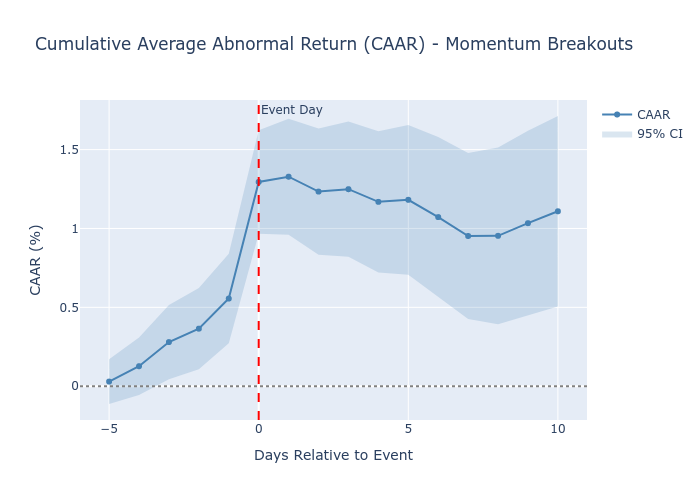

In [13]:
if len(result["daily_aar"]) > 0:
    daily_aar = result["daily_aar"]

    fig = go.Figure()

    days = daily_aar["day"].to_list()
    caar = daily_aar["caar"].to_numpy() * 100  # Convert to percent
    caar_se = daily_aar["caar_se"].to_numpy() * 100

    # CAAR line
    fig.add_trace(
        go.Scatter(
            x=days,
            y=caar,
            mode="lines+markers",
            name="CAAR",
            line=dict(color="steelblue", width=2),
        )
    )

    # 95% confidence band (CORRECT formula)
    upper = caar + 1.96 * caar_se
    lower = caar - 1.96 * caar_se

    fig.add_trace(
        go.Scatter(
            x=days + days[::-1],
            y=np.concatenate([upper, lower[::-1]]).tolist(),
            fill="toself",
            fillcolor="rgba(70, 130, 180, 0.2)",
            line=dict(width=0),
            name="95% CI",
        )
    )

    # Event day marker
    fig.add_vline(x=0, line_dash="dash", line_color="red", annotation_text="Event Day")
    fig.add_hline(y=0, line_dash="dot", line_color="gray")

    fig.update_layout(
        title="Cumulative Average Abnormal Return (CAAR) - Momentum Breakouts",
        xaxis_title="Days Relative to Event",
        yaxis_title="CAAR (%)",
        height=500,
    )

    fig.show()

In [14]:
# Print daily AAR and CAAR table
if len(result["daily_aar"]) > 0:
    daily_aar = result["daily_aar"]
    print("\nDaily AAR and CAAR:")
    print("-" * 80)
    print(f"{'Day':>5} {'AAR (%)':>10} {'t-stat':>10} {'CAAR (%)':>12} {'CAAR t':>10} {'n':>8}")
    print("-" * 80)

    for row in daily_aar.iter_rows(named=True):
        sig = "*" if abs(row["t_stat"]) > 1.96 else ""
        caar_sig = "*" if abs(row["caar_t_stat"]) > 1.96 else ""
        print(
            f"{row['day']:>5} {row['aar'] * 100:>10.3f} {row['t_stat']:>10.2f}{sig}"
            f" {row['caar'] * 100:>12.3f} {row['caar_t_stat']:>10.2f}{caar_sig} {row['n']:>8}"
        )

    print("-" * 80)
    print("* = significant at 5%")


Daily AAR and CAAR:
--------------------------------------------------------------------------------
  Day    AAR (%)     t-stat     CAAR (%)     CAAR t        n
--------------------------------------------------------------------------------
   -5      0.030       0.41        0.030       0.41      122
   -4      0.097       1.68        0.127       1.37      122
   -3      0.153       2.01*        0.280       2.33*      122
   -2      0.085       1.60        0.365       2.78*      122
   -1      0.191       3.12*        0.556       3.84*      122
    0      0.739       8.84*        1.295       7.74*      122
    1      0.033       0.39        1.328       7.08*      122
    2     -0.094      -1.16        1.234       6.04*      122
    3      0.015       0.20        1.249       5.71*      122
    4     -0.080      -1.23        1.169       5.12*      122
    5      0.013       0.16        1.182       4.88*      122
    6     -0.110      -1.21        1.072       4.14*      122
    7     -

## 4b. Library Alternative: EventStudyAnalysis

The manual implementation above teaches the MacKinlay (1997) mechanics.
The `ml4t-diagnostic` library adds robust variance adjustment (BMP test,
Boehmer et al. 1991) and non-parametric testing (Corrado rank test).

In [15]:
from ml4t.diagnostic.config import EventConfig
from ml4t.diagnostic.config.event_config import WindowSettings
from ml4t.diagnostic.evaluation import EventStudyAnalysis

# Prepare data in library format
# Returns: date, asset, return
lib_returns = returns_df.select(
    pl.col("timestamp").alias("date"),
    pl.col("symbol").alias("asset"),
    pl.col("return"),
)

# Benchmark: date, return
lib_benchmark = benchmark_returns.rename({"timestamp": "date", "benchmark_return": "return"})

# Events: date, asset
lib_events = events_df.select(
    pl.col("timestamp").alias("date"),
    pl.col("symbol").alias("asset"),
)

# Configure event study
config = EventConfig(
    window=WindowSettings(
        estimation_start=-60,
        estimation_end=-6,
        event_start=-5,
        event_end=10,
    ),
    model="market_model",
    min_estimation_obs=30,
)

# Run library event study
lib_analysis = EventStudyAnalysis(
    returns=lib_returns,
    events=lib_events,
    benchmark=lib_benchmark,
    config=config,
)
lib_result = lib_analysis.run()

In [16]:
# Compare results
print("=== Library EventStudyAnalysis Results ===\n")
print(lib_result.summary())

# The library adds tests not in the manual implementation:
print("\n=== Additional Statistical Tests ===")
if hasattr(lib_result, "bmp_test"):
    print(f"BMP test (robust to event-induced variance): t={lib_result.bmp_test['t_stat']:.2f}")
if hasattr(lib_result, "corrado_test"):
    print(f"Corrado rank test (non-parametric): z={lib_result.corrado_test['z_stat']:.2f}")

=== Library EventStudyAnalysis Results ===

EVENT STUDY RESULTS
Events analyzed: 122
Event window: [-5, 10]
Model: market_model

CUMULATIVE AVERAGE ABNORMAL RETURN (CAAR)
  Event day AAR (t=0): +0.0074 (+0.74%)
  Final CAAR: +0.0111 (+1.11%)
  95% CI: [0.0096, 0.0125]

STATISTICAL TEST
  Test: boehmer
  Test statistic: 3.0177
  P-value: 0.0025
  Result: significant at α=0.05

=== Additional Statistical Tests ===


The manual implementation teaches the market model ($R_i = \alpha + \beta R_m$)
and CAAR computation. The library adds:

| Feature | Manual | Library |
|---------|--------|---------|
| Market model | Yes | Yes |
| Mean-adjusted model | No | Yes |
| BMP test (robust variance) | No | Yes |
| Corrado rank test | No | Yes |
| Event clustering handling | No | Yes |

## 5. CAR Distribution

Examining the distribution of individual event CARs reveals whether the
aggregate effect is driven by many small effects or few large ones.

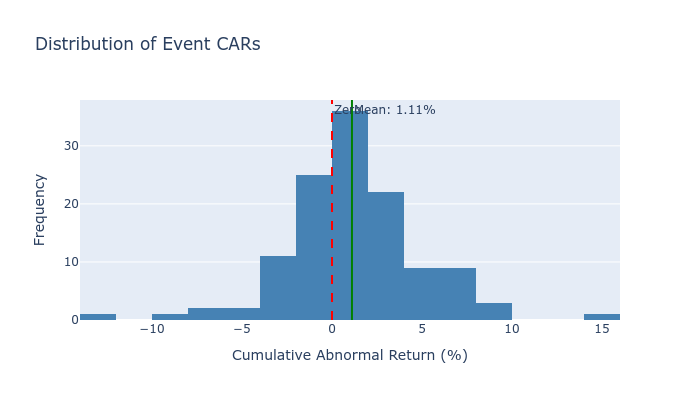


Statistical Test (H0: Mean CAR = 0):
  Mean CAR: 1.11%
  Median CAR: 0.61%
  T-statistic: 3.28
  P-value: 0.0014
  Significant at 5%: Yes


In [17]:
if len(result["event_cars"]) > 0:
    cars = result["event_cars"]["car"].to_numpy() * 100

    fig = go.Figure()

    fig.add_trace(
        go.Histogram(
            x=cars,
            nbinsx=25,
            marker_color="steelblue",
            name="CAR Distribution",
        )
    )

    # Mean and zero lines
    fig.add_vline(x=0, line_dash="dash", line_color="red", annotation_text="Zero")
    fig.add_vline(
        x=np.mean(cars),
        line_dash="solid",
        line_color="green",
        annotation_text=f"Mean: {np.mean(cars):.2f}%",
    )

    fig.update_layout(
        title="Distribution of Event CARs",
        xaxis_title="Cumulative Abnormal Return (%)",
        yaxis_title="Frequency",
        height=400,
    )

    fig.show()

    # Statistical test: Mean CAR = 0
    t_stat, p_value = stats.ttest_1samp(cars, 0)

    print("\nStatistical Test (H0: Mean CAR = 0):")
    print(f"  Mean CAR: {np.mean(cars):.2f}%")
    print(f"  Median CAR: {np.median(cars):.2f}%")
    print(f"  T-statistic: {t_stat:.2f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")

**Interpretation**: A right-skewed CAR distribution with a statistically significant
positive mean suggests that momentum breakouts are followed by genuine abnormal
returns -- not just a few outlier events. If the distribution were bimodal or
heavily skewed by a handful of events, the aggregate CAAR would be unreliable
for strategy design. The mean/median comparison also matters: if the median is
near zero but the mean is positive, a few large events drive the result.

## 6. Event Study Heatmap

Visualize abnormal returns across events and days to identify patterns.

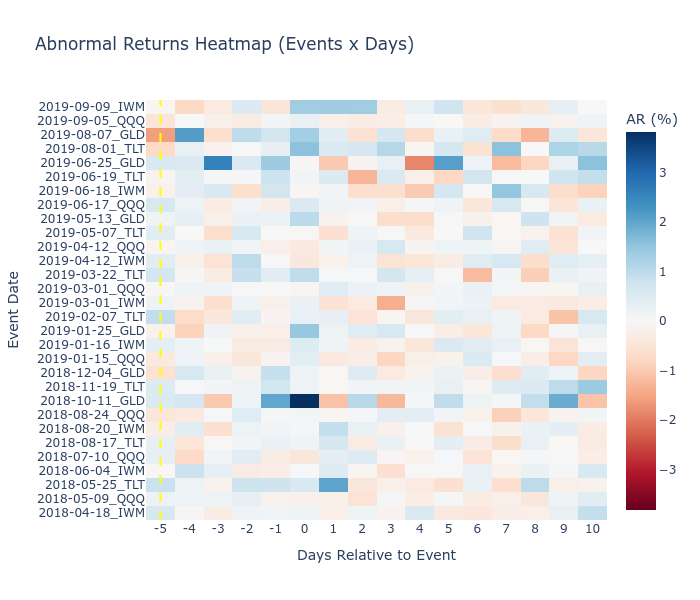

In [18]:
if len(result["abnormal_returns"]) > 0:
    ar_df = result["abnormal_returns"]

    # Create unique event identifier (date + symbol can have multiple events)
    ar_df = ar_df.with_columns(
        (pl.col("event_date").dt.strftime("%Y-%m-%d") + "_" + pl.col("symbol")).alias("event_id")
    )

    # Pivot to wide format (event x day)
    ar_pivot = ar_df.pivot(on="day", index="event_id", values="ar").sort("event_id")

    # Convert to numpy for heatmap
    day_cols = sorted([c for c in ar_pivot.columns if c != "event_id"], key=lambda x: int(x))
    ar_matrix = ar_pivot.select(day_cols).to_numpy() * 100

    # Limit to 30 events for readability
    if len(ar_matrix) > 30:
        ar_matrix = ar_matrix[:30]
        event_ids = ar_pivot["event_id"].to_list()[:30]
    else:
        event_ids = ar_pivot["event_id"].to_list()

    fig = go.Figure(
        data=go.Heatmap(
            z=ar_matrix,
            x=day_cols,
            y=event_ids,
            colorscale="RdBu",
            zmid=0,
            colorbar=dict(title="AR (%)"),
        )
    )

    fig.add_vline(x=0, line_dash="dash", line_color="yellow", line_width=2)

    fig.update_layout(
        title="Abnormal Returns Heatmap (Events x Days)",
        xaxis_title="Days Relative to Event",
        yaxis_title="Event Date",
        height=600,
    )

    fig.show()

## 7. Caveats and Best Practices

### Event Clustering

When multiple events occur on the same day (e.g., sector-wide announcements),
the cross-sectional correlation inflates the t-statistics. Solutions:
- Use portfolio-level returns
- Adjust standard errors for clustering
- Aggregate to one "event" per day

### Overlapping Windows

If events are close together, estimation and event windows may overlap,
contaminating the "normal return" estimate. Solutions:
- Enforce minimum gap between events (we used 30 days)
- Use shorter estimation windows
- Use calendar-time portfolio approach

### Confounding Events

Other events in the window (earnings, macro news) can confound results.
Solutions:
- Screen for confounding events
- Use matched controls
- Analyze subsamples

## 8. Using Event Studies for Signal Validation

Event studies validate trading signals by testing whether signal-generated
"events" produce abnormal returns.

In [19]:
def validate_signal_with_event_study(
    returns_df: pl.DataFrame,
    benchmark_df: pl.DataFrame,
    signal_df: pl.DataFrame,
    signal_column: str = "signal",
    threshold: float = 2.0,
    event_window: tuple[int, int] = (-5, 10),
) -> dict:
    """
    Validate a trading signal using event study methodology.

    Parameters
    ----------
    returns_df : Long-format returns
    benchmark_df : Benchmark returns
    signal_df : Signal values (timestamp, symbol, signal)
    signal_column : Column name for signal
    threshold : Z-score threshold for event trigger
    event_window : Days around event to analyze

    Returns
    -------
    Dict with long and short event study results
    """
    # Z-score signals cross-sectionally
    signal_zscored = signal_df.with_columns(
        (
            (pl.col(signal_column) - pl.col(signal_column).mean().over("timestamp"))
            / pl.col(signal_column).std().over("timestamp")
        ).alias("zscore")
    )

    # Generate events from extreme signals
    long_events = (
        signal_zscored.filter(pl.col("zscore") > threshold)
        .select(["timestamp", "symbol"])
        .with_columns(pl.lit("long_signal").alias("event_type"))
    )

    short_events = (
        signal_zscored.filter(pl.col("zscore") < -threshold)
        .select(["timestamp", "symbol"])
        .with_columns(pl.lit("short_signal").alias("event_type"))
    )

    print(f"Long signal events: {len(long_events)}")
    print(f"Short signal events: {len(short_events)}")

    results = {}

    if len(long_events) > 10:
        results["long"] = compute_event_study(
            returns_df, benchmark_df, long_events, event_window=event_window
        )

    if len(short_events) > 10:
        results["short"] = compute_event_study(
            returns_df, benchmark_df, short_events, event_window=event_window
        )

    return results

In [20]:
# Example: Validate momentum signal
# Create momentum signal
prices_wide = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
)

symbols = [c for c in prices_wide.columns if c != "timestamp"]

# 21-day momentum
momentum = prices_wide.select(
    pl.col("timestamp"), *[(pl.col(s) / pl.col(s).shift(21) - 1).alias(s) for s in symbols]
)

# Melt to long format
momentum_long = (
    momentum.unpivot(index="timestamp", variable_name="symbol", value_name="momentum")
    .drop_nulls()
    .filter(pl.col("momentum").is_finite())
)

print(f"Momentum signal: {len(momentum_long):,} observations")

Momentum signal: 7,440 observations


In [21]:
# Validate momentum signal
validation = validate_signal_with_event_study(
    returns_df.select(["timestamp", "symbol", "return"]),
    benchmark_returns,
    momentum_long,
    signal_column="momentum",
    threshold=1.5,
)

if "long" in validation and len(validation["long"]["daily_aar"]) > 0:
    print("\nLong Signal Validation:")
    aar_long = validation["long"]["daily_aar"]
    final_caar = aar_long["caar"].to_numpy()[-1] * 100
    final_t = aar_long["caar_t_stat"].to_numpy()[-1]
    print(f"  Final CAAR: {final_caar:.2f}%")
    print(f"  CAAR t-stat: {final_t:.2f}")
    print(f"  Significant: {'Yes' if abs(final_t) > 1.96 else 'No'}")

if "short" in validation and len(validation["short"]["daily_aar"]) > 0:
    print("\nShort Signal Validation:")
    aar_short = validation["short"]["daily_aar"]
    final_caar = aar_short["caar"].to_numpy()[-1] * 100
    final_t = aar_short["caar_t_stat"].to_numpy()[-1]
    print(f"  Final CAAR: {final_caar:.2f}%")
    print(f"  CAAR t-stat: {final_t:.2f}")
    print(f"  Significant: {'Yes' if abs(final_t) > 1.96 else 'No'}")

Long signal events: 228
Short signal events: 329



Long Signal Validation:
  Final CAAR: 0.87%
  CAAR t-stat: 3.30
  Significant: Yes

Short Signal Validation:
  Final CAAR: -0.25%
  CAAR t-stat: -1.31
  Significant: No


## 9. Summary

### Methodology

- **Estimation window**: 60 days before event (excluding 5-day gap)
- **Event window**: 5 days before to 10 days after
- **Model**: Market model ($R_i = \alpha + \beta \cdot R_{market}$)

### Key Formulas

| Metric | Formula |
|--------|---------|
| Abnormal Return | $AR = R_{actual} - (\alpha + \beta \cdot R_{market})$ |
| CAR | Cumulative sum of AR over event window |
| CAAR | Average CAR across events |
| CAAR SE | $\sqrt{\sum_{s=1}^{t} \text{Var}(AAR_s) / n}$ |

### Interpretation Guide

| Pattern | Meaning | Trading Implication |
|---------|---------|---------------------|
| Pre-event drift | Information leakage | Limited post-event alpha |
| Event-day jump | Clean announcement | Event timing matters |
| Post-event drift | Underreaction | Post-event momentum |
| Reversal | Overreaction | Mean-reversion |

### Caveats

- Event clustering inflates t-stats
- Overlapping windows contaminate estimates
- Confounding events require screening

## Key Takeaways

1. **Proper indexing matters**: Use aligned DataFrames, not `get_loc()` on
   potentially non-unique indices.

2. **CAAR variance is cumulative**: SE(CAAR_t) = sqrt(sum of daily variances),
   not a simple propagation formula.

3. **Event studies validate signals**: Signal-triggered "events" should produce
   significant abnormal returns if the signal has predictive power.

4. **Watch for clustering**: Events on the same day violate independence
   assumptions underlying the t-tests.

5. **Minimum gap prevents overlap**: Enforce at least 20-30 day gaps between
   events per symbol to keep estimation windows clean.

### Next Notebook

- `case_study_feature_summary` — cross-case-study feature inventory